In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("bmi.csv", encoding="utf-8")
df.head()

,height,weight,label
0,142,62,fat
1,142,73,fat
2,177,61,normal
3,187,48,thin
4,153,60,fat


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   height  20000 non-null  int64
 1   weight  20000 non-null  int64
 2   label   20000 non-null  str  
dtypes: int64(2), str(1)
memory usage: 468.9 KB


In [12]:
# 상위 데이터 100개 중 height와 weight만 사용
df_bmi = df.iloc[:100, :2]

df_bmi.head()

,height,weight
0,142,62
1,142,73
2,177,61
3,187,48
4,153,60


In [13]:
df_bmi.tail()

,height,weight
95,136,51
96,131,37
97,180,75
98,191,60
99,126,55


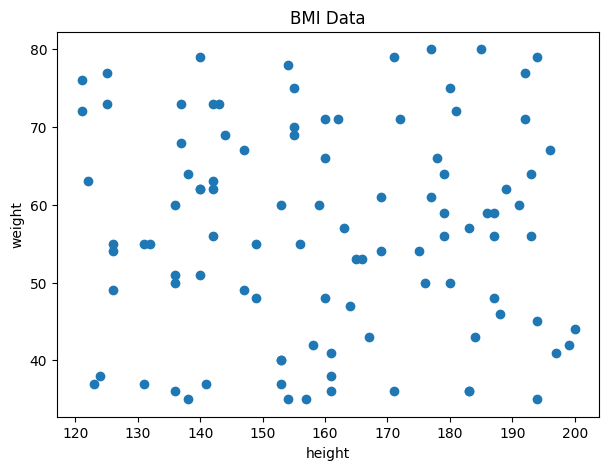

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(df_bmi.iloc[:, 0], df_bmi.iloc[:, 1])
plt.title("BMI Data")
plt.xlabel("height")
plt.ylabel("weight")
plt.show()

# (1) K-means clustering

In [15]:
from sklearn.cluster import KMeans

# K-means 모델 생성
km = KMeans(n_clusters=3, random_state=1)

# 모델 학습
km.fit(df_bmi)

# 클러스터 예측
y_pred = km.predict(df_bmi)

y_pred

array([1, 1, 0, 0, 1, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 1, 1, 0,
       2, 2, 0, 1, 0, 1, 1, 0, 2, 2, 1, 0, 0, 1, 2, 1, 1, 2, 0, 0, 1, 1,
       0, 0, 1, 0, 2, 2, 0, 0, 0, 2, 0, 2, 2, 2, 1, 1, 0, 1, 0, 1, 2, 2,
       2, 0, 0, 1, 1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 1, 2, 1, 0, 1, 1, 1, 0,
       1, 2, 1, 0, 2, 0, 0, 1, 2, 0, 0, 1], dtype=int32)

In [16]:
# 클러스터 중심점
c0, c1, c2 = km.cluster_centers_

print(c0)
print(c1)
print(c2)

[184.71052632  58.28947368]
[139.13157895  63.21052632]
[155.16666667  43.25      ]


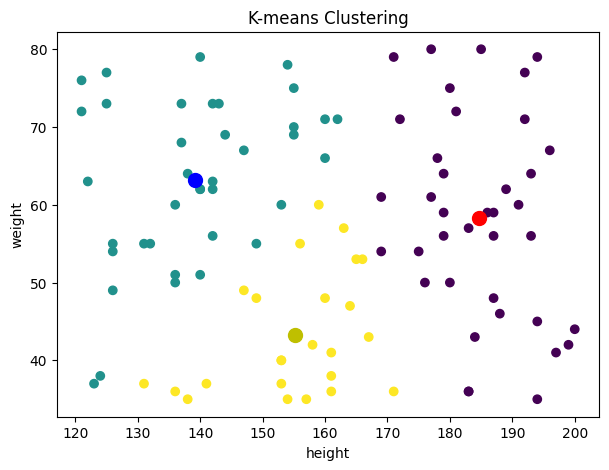

In [17]:
# K-means clustering 결과 시각화
plt.figure(figsize=(7, 5))

plt.scatter(df_bmi.iloc[:, 0], df_bmi.iloc[:, 1], c=y_pred)

# 중심점 표시
plt.scatter(c0[0], c0[1], s=100, c='r')
plt.scatter(c1[0], c1[1], s=100, c='b')
plt.scatter(c2[0], c2[1], s=100, c='y')

plt.title("K-means Clustering")
plt.xlabel("height")
plt.ylabel("weight")
plt.show()

# (2) AgglomerativeClustering

In [18]:
from sklearn.cluster import AgglomerativeClustering

# AgglomerativeClustering 모델 생성
hier = AgglomerativeClustering(n_clusters=3, metric="euclidean")

# 모델 학습
hier.fit(df_bmi)

# 클러스터 결과
y_pred_hier = hier.labels_

y_pred_hier

array([0, 0, 1, 1, 2, 1, 2, 1, 1, 1, 0, 0, 1, 1, 0, 2, 0, 0, 2, 0, 0, 1,
       2, 2, 1, 0, 1, 0, 0, 1, 2, 2, 0, 1, 1, 0, 2, 0, 0, 0, 1, 1, 0, 0,
       1, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 2, 1, 2, 0, 0, 1, 0, 1, 0, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 2, 2, 1, 0, 0, 2, 0, 1, 0, 0, 0, 1,
       0, 2, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0])

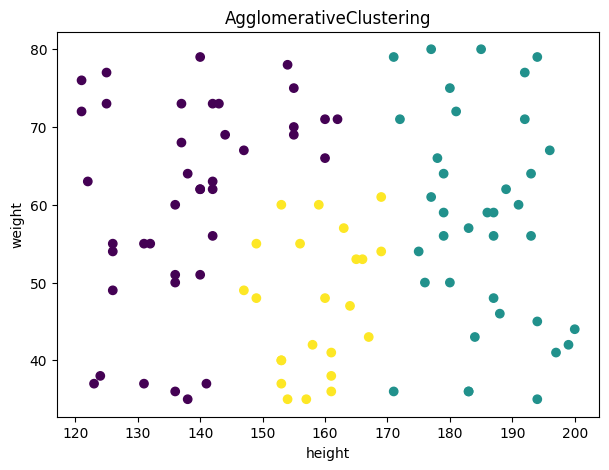

In [19]:
# AgglomerativeClustering 결과 시각화
plt.figure(figsize=(7, 5))

plt.scatter(df_bmi.iloc[:, 0], df_bmi.iloc[:, 1], c=y_pred_hier)

plt.title("AgglomerativeClustering")
plt.xlabel("height")
plt.ylabel("weight")
plt.show()